In [3]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from utils.utils import *
from models.lstm import *
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
btc_df = yf.download('BTC-USD', interval='1m', period='5d')
btc_df.reset_index(inplace=True)
btc_df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)
btc_df.rename(columns={'Datetime': 'time', 'Adj Close': 'price'}, inplace=True)

[*********************100%%**********************]  1 of 1 completed


In [6]:
INIT_PRICE = 66115

In [7]:
WINDOW = 10
features, targets = preprocess_data(btc_df, WINDOW)
X_train, y_train, X_test, y_test = split_train_test(features, targets)

# LSTM

In [8]:
model = train_lstm(X_train, y_train, X_test, y_test, WINDOW)
y_pred = (model.predict(X_test)).reshape(-1)

Epoch 1/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0374 - val_loss: 9.8310e-05
Epoch 2/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 3/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0037 - val_loss: 5.8885e-04
Epoch 4/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 5/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0030 - val_loss: 2.2357e-04
Epoch 6/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0020 - val_loss: 3.5147e-05
Epoch 7/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0018 - val_loss: 1.7528e-04
Epoch 8/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0016 - val_loss: 3.3912e-05
Epoch 9/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0013 - val_loss: 1.8497e-04
Epoch 10/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0012 - val_loss: 2.1335e-04
Epoch 11/128
629/629 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 0.0013 - val_loss: 2.32

# LSTM + Linear

In [11]:
lstm_base, lr_model = build_lstm_linear(X_train, y_train, X_test, y_test, WINDOW)

Epoch 1/128


InvalidArgumentError: Graph execution error:

Detected at node gradient_tape/compile_loss/mean_squared_error/sub/BroadcastGradientArgs defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\eugen\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\eugen\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\eugen\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "C:\Users\eugen\AppData\Roaming\Python\Python312\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Program Files\Python312\Lib\asyncio\base_events.py", line 639, in run_forever

  File "c:\Program Files\Python312\Lib\asyncio\base_events.py", line 1985, in _run_once

  File "c:\Program Files\Python312\Lib\asyncio\events.py"

In [10]:
lstm_X_test = lstm_base.predict(X_test)
y_pred2 = lr_model.predict(lstm_X_test)

NameError: name 'lstm_base' is not defined

# LSTM + XGBoost

In [18]:
lstm_xgb, xgboost = build_lstm_xgboost(X_train, y_train, X_test, y_test, WINDOW)

Epoch 1/128
527/527 [==============================] - 6s 10ms/step - loss: 0.0290 - val_loss: 2.6606e-04
Epoch 2/128
527/527 [==============================] - 5s 10ms/step - loss: 0.0072 - val_loss: 0.0025
Epoch 3/128
527/527 [==============================] - 5s 10ms/step - loss: 0.0055 - val_loss: 4.9055e-04
Epoch 4/128
527/527 [==============================] - 5s 9ms/step - loss: 0.0045 - val_loss: 1.9511e-04
Epoch 5/128
527/527 [==============================] - 5s 10ms/step - loss: 0.0040 - val_loss: 3.8264e-04
Epoch 6/128
527/527 [==============================] - 5s 10ms/step - loss: 0.0034 - val_loss: 2.0553e-04
Epoch 7/128
527/527 [==============================] - 5s 10ms/step - loss: 0.0026 - val_loss: 1.4949e-04
Epoch 8/128
527/527 [==============================] - 6s 11ms/step - loss: 0.0020 - val_loss: 6.2972e-05
Epoch 9/128
527/527 [==============================] - 6s 11ms/step - loss: 0.0016 - val_loss: 3.5577e-05
Epoch 10/128
527/527 [=============================

In [58]:
lstm_xgb_X_test = lstm_xgb.predict(X_test)
y_pred3 = xgboost.predict(lstm_xgb_X_test)

19/19 [==============================] - 0s 9ms/step


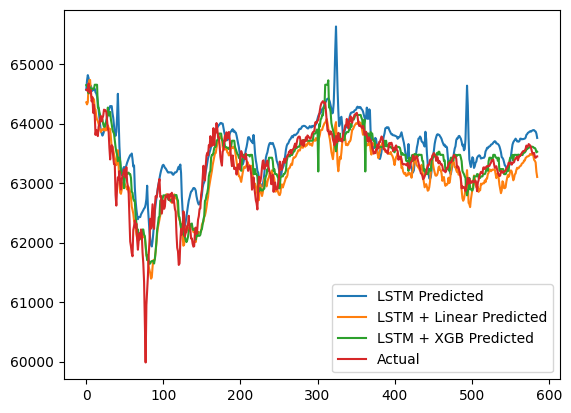

In [79]:
plt.plot(y_pred*INIT_PRICE, label='LSTM Predicted')
plt.plot(y_pred2*INIT_PRICE, label='LSTM + Linear Predicted')
plt.plot(y_pred3*INIT_PRICE, label='LSTM + XGB Predicted')
plt.plot(y_test*INIT_PRICE, label='Actual')
plt.legend()

In [109]:
from sklearn.metrics import mean_squared_error, accuracy_score

In [83]:
print(f'LSTM MSE: {mean_squared_error(y_test, y_pred):.8f}\n'
      f'LSTM+Linear MSE: {mean_squared_error(y_test, y_pred2):.8f}\n'
      f'LSTM+XGB MSE: {mean_squared_error(y_test, y_pred3):.8f}')

LSTM MSE: 0.00006106
LSTM+Linear MSE: 0.00002406
LSTM+XGB MSE: 0.00002408


In [108]:
def trend_calc(y):
    y = pd.Series(y)
    return np.sign(y[1:] - y.shift(1).dropna())

In [110]:
y_test_trend = trend_calc(y_test)
y_pred_trend = trend_calc(y_pred)
y_pred2_trend = trend_calc(y_pred2)
y_pred3_trend = trend_calc(y_pred3)

print(f'LSTM Accuracy: {accuracy_score(y_test_trend, y_pred_trend):.8f}\n'
      f'LSTM+Linear Accuracy: {accuracy_score(y_test_trend, y_pred2_trend):.8f}\n'
      f'LSTM+XGB Accuracy: {accuracy_score(y_test_trend, y_pred3_trend):.8f}')

LSTM Accuracy: 0.51111111
LSTM+Linear Accuracy: 0.51623932
LSTM+XGB Accuracy: 0.34871795


## TODO: yfinance Realtime Data

In [91]:
real_btc_df = yf.download('BTC-USD', interval='1m', period='1d')
real_btc_df.reset_index(inplace=True)
real_btc_df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)
real_btc_df.rename(columns={'Datetime': 'time', 'Adj Close': 'price'}, inplace=True)
real_btc_df.time = pd.to_datetime(real_btc_df.time)

[*********************100%%**********************]  1 of 1 completed


In [97]:
# # btc_df[['time', 'price']]
# unseen_df = real_btc_df[(real_btc_df.time > btc_df.time.max())]
# real_btc_df.iloc[-1] / INIT_PRICE

In [ ]:
# end_time = datetime.now() + timedelta(minutes=3)

# while datetime.now() < end_time:

In [174]:
# # Main function
# def main():
#     data_storage = []
#     WINDOW = 12
#     CAPITAL = 10000
#     QUANTITY = 0
#     trading_history = []
#     end_time = datetime.now() + timedelta(hours=2)
#     hist_df = fetch_historical_data(granularity=300)
    
#     while datetime.now() < end_time:
#         real = fetch_real_time_latest_data()
        
#         if hist_df.time.max() < real.time[0]:
#             hist_df = pd.concat([hist_df, real])
        
        
#         print(real.time)

#         current_price = real['price'][0]
#         init_price = hist_df['price'].iloc[0] 
#         hist_df['price'] = hist_df['price']/init_price

#         features, _ = preprocess_data(hist_df, window=WINDOW)
        
#         current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
#         current_features = features.iloc[-1].values.reshape(1, 72)
#         predicted_price = model.predict(current_features)[0][0]
#         predicted_price_value = float(predicted_price * init_price)
        

#         # Append the data to the list instead of storing in the database
#         data_storage.append((current_time, current_price, predicted_price_value))

#         # Print the data storage list as a DataFrame
#         print(pd.DataFrame(data_storage, columns=["Timestamp", "Current Price", "Predicted Price"]))

#         print(f"Data stored for time: {current_time}")
#         print(f"Current Price: {current_price}")
#         print(f"Predicted Price After 5 Minutes: {predicted_price_value}")
#         CAPITAL, QUANTITY, trading_history = trade(predicted_price, current_price, CAPITAL, QUANTITY, trading_history)
#         print(f'Current Capital: ${CAPITAL} and Current Quantity: {QUANTITY}')
#         print("Waiting for 5 minutes before next iteration...")

#         time.sleep(300)
#     return data_storage, CAPITAL, QUANTITY, trading_history


In [1]:
# data_stroage, capital, quantity, trading_history = main()